In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

pd.set_option('display.max_columns', None)

/blue/juannanzhou/palash.sethi/conda/envs/esm2/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [4]:
#this df was created using va.merge_vep()
vep_df = pd.read_csv("/orange/juannanzhou/VEP/vep_df_10August.csv")

/scratch/local/9771218/ipykernel_2611075/4192689194.py:2: DtypeWarning: Columns (6,14,60,63,64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  vep_df = pd.read_csv("/orange/juannanzhou/VEP/vep_df_10August.csv")


In [5]:
vep_df.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000377001:292A>V,NP_001007227.1,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,V299M,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,Benign,-2.586828,wt-marginals,False,esm1_t6_43M_UR50S,clinical_ProteinGym_substitutions,ENSP00000377001,ENST00000393328,False,17,49601950,2343769,C,T,.,PASS,2343769,17:49601950,T,8405,NM_001007226.1,Transcript,missense_variant,1366,895,299,V/M,Gtg/Atg,-,MODERATE,-,-1,-,-,-,C,C,OK,NM_001007226.1:c.895G>A,NP_001007227.1:p.Val299Met,-,NaN,NaN,2337917,"MeSH:D030342,MedGen:C0950123",Inborn_genetic_diseases,NC_000017.11:g.49601950C>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,SPOP:8405,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,-5.533481,-3.083569,-5.764221,-0.020301,9,likely_benign
1,ENSP00000377001:292A>V,NP_001007227.1,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,E160K,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,Pathogenic,-4.634233,wt-marginals,False,esm1_t6_43M_UR50S,clinical_ProteinGym_substitutions,ENSP00000377001,ENST00000393328,False,17,49618983,694199,C,T,.,PASS,694199,17:49618983,T,8405,NM_001007226.1,Transcript,"missense_variant,splice_region_variant",949,478,160,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,OK,NM_001007226.1:c.478G>A,NP_001007227.1:p.Glu160Lys,-,NaN,NaN,681927,"MONDO:MONDO:0032942,MedGen:C5394218,OMIM:61882...",Neurodevelopmental_disorder_with_microcephaly_...,NC_000017.11:g.49618983C>T,"criteria_provided,_single_submitter",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,SPOP:8405,SO:0001583|missense_variant,3,2072151207.0,NaN,NaN,NaN,NaN,NaN,-3.758031,-1.408996,-8.646988,-0.034355,9,path
2,ENSP00000377001:292A>V,NP_001007227.1,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,D144N,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,Pathogenic,-2.02246,wt-marginals,False,esm1_t6_43M_UR50S,clinical_ProteinGym_substitutions,ENSP00000377001,ENST00000393328,False,17,49619031,830356,C,T,.,PASS,830356,17:49619031,T,8405,NM_001007226.1,Transcript,missense_variant,901,430,144,D/N,Gat/Aat,-,MODERATE,-,-1,-,-,-,C,C,OK,NM_001007226.1:c.430G>A,NP_001007227.1:p.Asp144Asn,-,NaN,NaN,818728,"MONDO:MONDO:0032942,MedGen:C5394218,OMIM:618828",Neurodevelopmental_disorder_with_microcephaly_...,NC_000017.11:g.49619031C>T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,SPOP:8405,SO:0001583|missense_variant,1,2072153488.0,NaN,OMIM:602650.0003,NaN,NaN,NaN,-3.844755,-0.168743,-6.637349,-0.017480,9,likely_path
3,ENSP00000377001:292A>V,NP_001007227.1,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,R138C,MSRVPSPPPPAEMSSGPVAESWCYTQIKVVKFSYMWTINNFSFCRE...,Pathogenic,0.352461,wt-marginals,False,esm1_t6_43M_UR50S,clinical_ProteinGym_substitutions,ENSP00000377001,ENST00000393328,False,17,49619049,830359,G,A,.,PASS,830359,17:49619049,A,8405,NM_001007226.1,Transcript,missense_variant,883,412,138,R/C,Cgt/Tgt,-,MODERATE,-,-1,-,-,-,G,G,OK,NM_001007226.1:c.412C>T,NP_001007227.1:p.Arg138Cys,-,NaN,NaN,818731,"MONDO:MONDO:0032943,MedGen:C5394221,OMIM:61882...",Neurodevelopmental_disorder_with_relative_macr...,NC_000017.11:g.49619049G>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,SPOP:8405,SO:0001583|m

In [11]:
import numpy as np
import ast

def to_float_or_first(x):
    if isinstance(x, str) and x.strip().startswith("[") and x.strip().endswith("]"):
        try:
            arr = np.array(ast.literal_eval(x))
            return float(arr[0])
        except:
            return np.nan
    elif isinstance(x, (list, tuple, np.ndarray)):
        return float(x[0])
    else:
        try:
            return float(x)
        except:
            return np.nan

vep_df['VEP'] = vep_df['VEP'].apply(to_float_or_first)

In [12]:
vep_df.VEP

0            -2.586828
1            -4.634233
2            -2.022460
3             0.352461
4            -0.713595
               ...    
10563524    150.869629
10563525    153.194046
10563526    150.121719
10563527    155.376282
10563528    155.327087
Name: VEP, Length: 10563529, dtype: float64

100%|██████████| 4/4 [00:00<00:00, 896.84it/s]


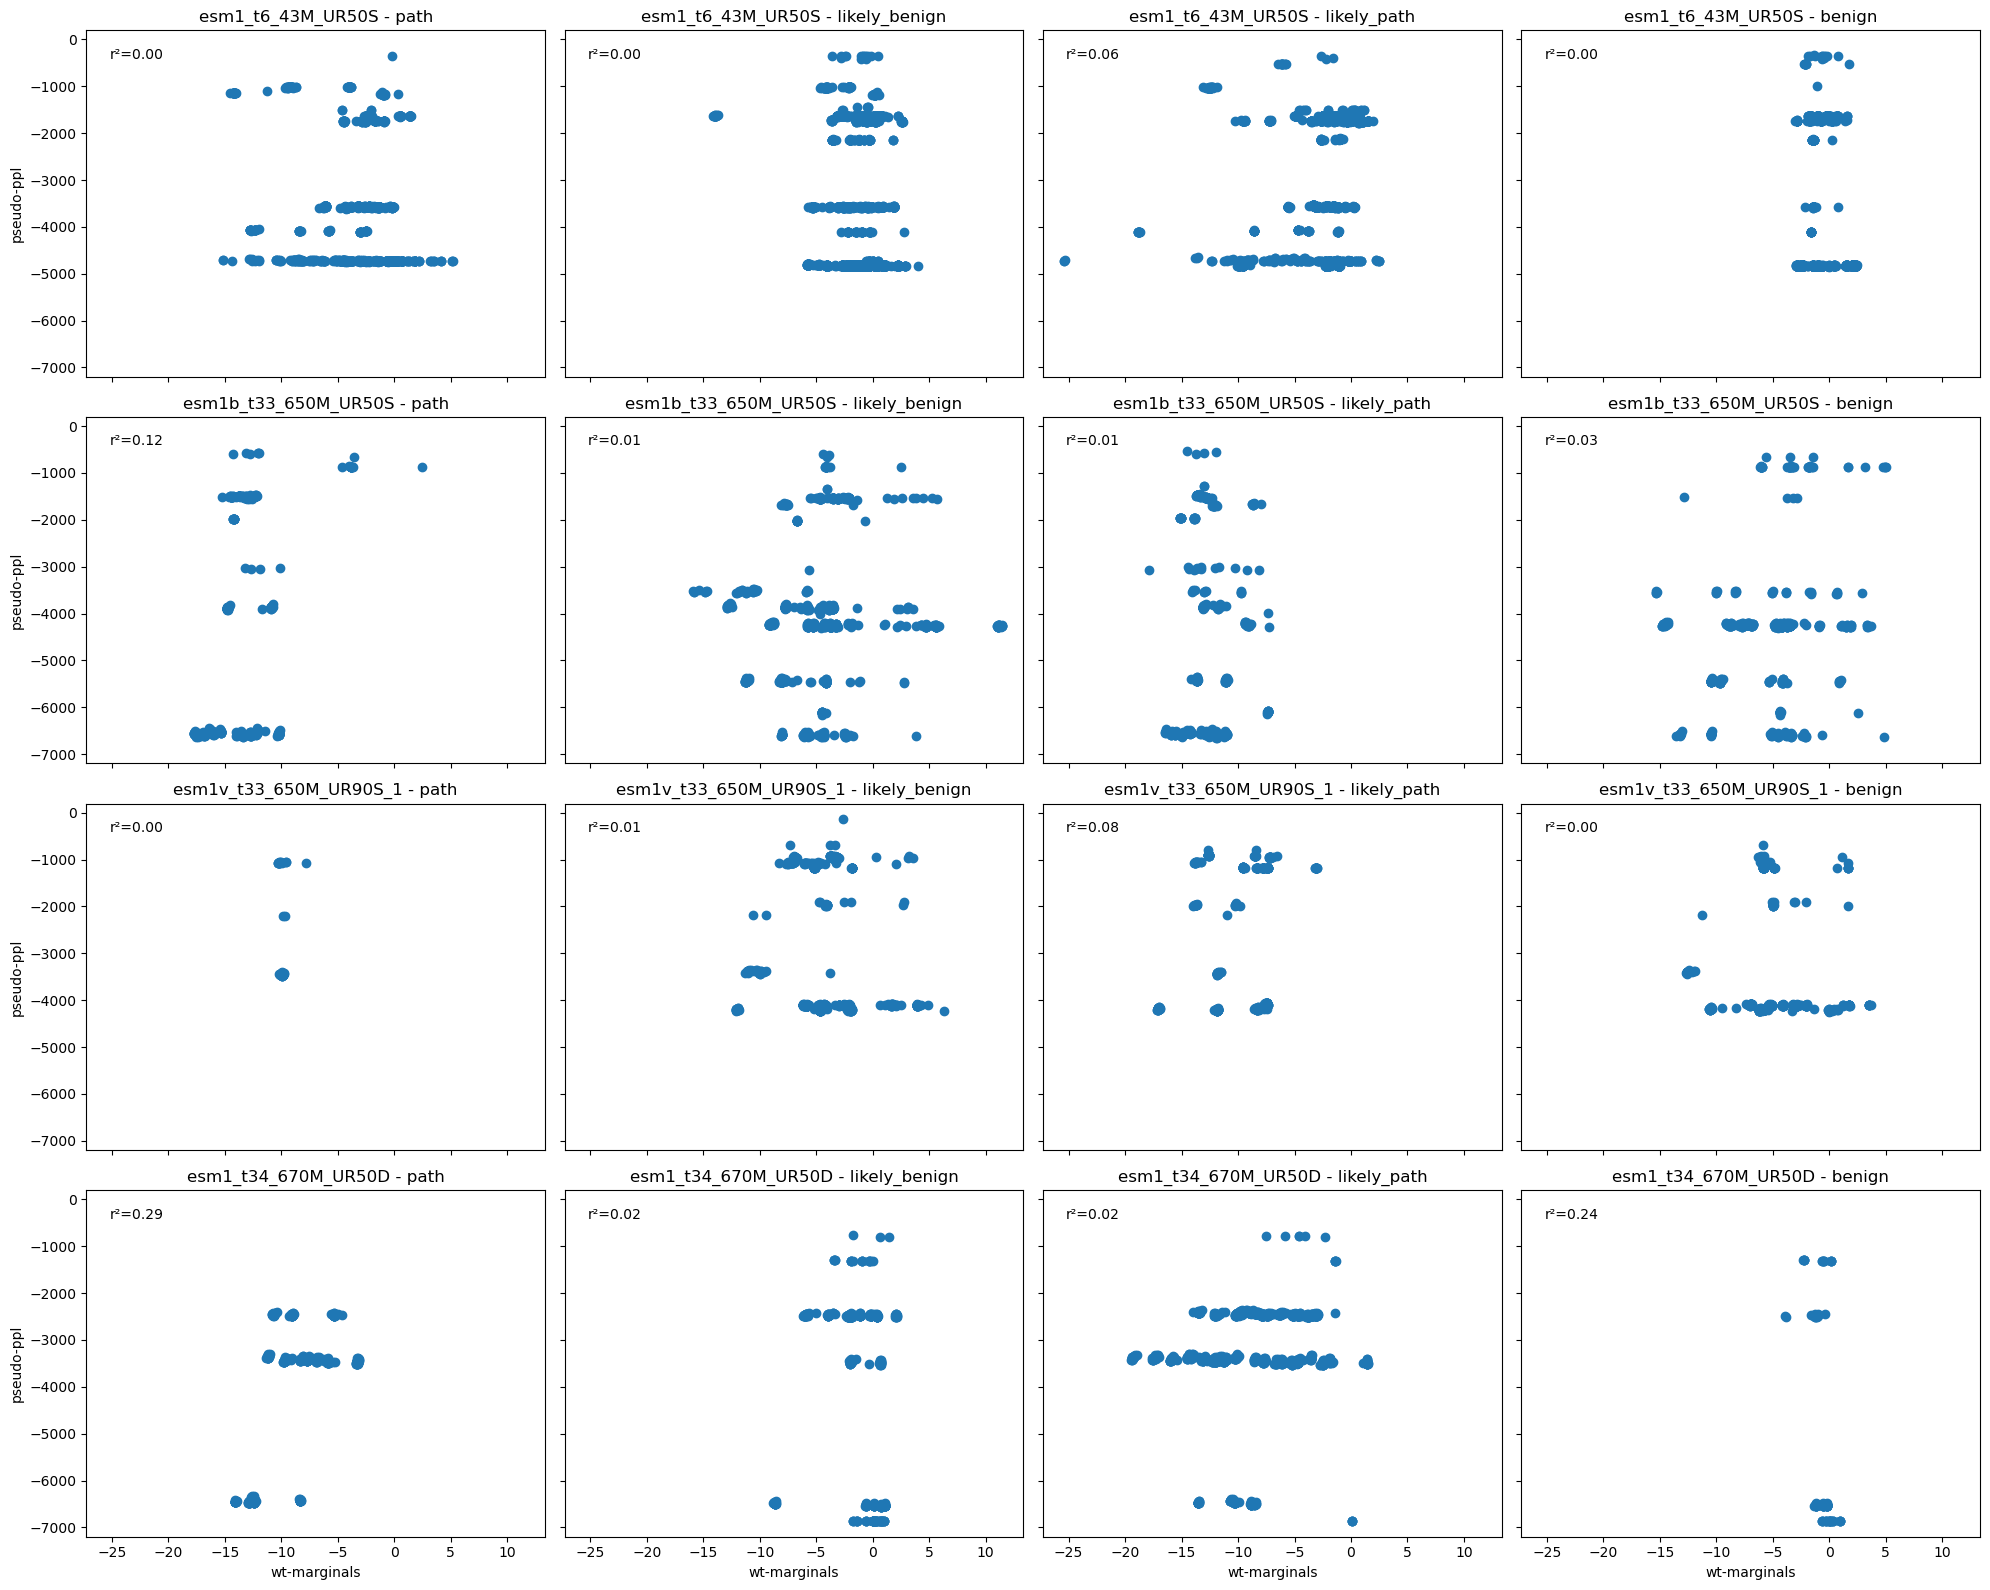

In [13]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# keep only needed strategies
df = vep_df[vep_df['scoring_strategy'].isin(['wt-marginals', 'pseudo-ppl'])]

# pivot, include clinsig
pt = df.pivot_table(index=['haplotype','protein','mutant','model_location','clinsig'],
                    columns='scoring_strategy', values='VEP', aggfunc='first')

# require both present
pt = pt.dropna(subset=['wt-marginals','pseudo-ppl']).reset_index()

# colormap for clinsig
clinsig_unique = pt['clinsig'].unique()
color_map = {val: i for i, val in enumerate(clinsig_unique)}

# build dict
models = pt['model_location'].unique()
agg = {}
for m in tqdm(models, total=len(models)):
    g = pt[pt['model_location'] == m]
    agg[m] = {
        'wt-marginals': g['wt-marginals'].tolist(),
        'pseudo-ppl': g['pseudo-ppl'].tolist(),
        'clinsig': [color_map[val] for val in g['clinsig']]
    }

from scipy.stats import pearsonr

fig, axes = plt.subplots(len(models), len(clinsig_unique),
                         figsize=(5*len(clinsig_unique), 4*len(models)),
                         sharex=True, sharey=True)

for i, m in enumerate(models):
    g = pt[pt['model_location'] == m]
    for j, cls in enumerate(clinsig_unique):
        sub = g[g['clinsig'] == cls]
        axes[i, j].scatter(sub['wt-marginals'], sub['pseudo-ppl'])
        
        if len(sub) > 1:
            r, _ = pearsonr(sub['wt-marginals'], sub['pseudo-ppl'])
            axes[i, j].text(0.05, 0.95, f"r²={r**2:.2f}",
                            transform=axes[i, j].transAxes,
                            ha='left', va='top', fontsize=10)

        axes[i, j].set_title(f"{m} - {cls}")
        if i == len(models)-1:
            axes[i, j].set_xlabel('wt-marginals')
        if j == 0:
            axes[i, j].set_ylabel('pseudo-ppl')

plt.tight_layout()
# plt.savefig('/blue/juannanzhou/palash.sethi/Projects/VEP/VEP_protein/palash_analysis_scripts/results/ppl_vs_wt_correlation.png')
plt.show()




100%|██████████| 4/4 [00:00<00:00, 922.43it/s]


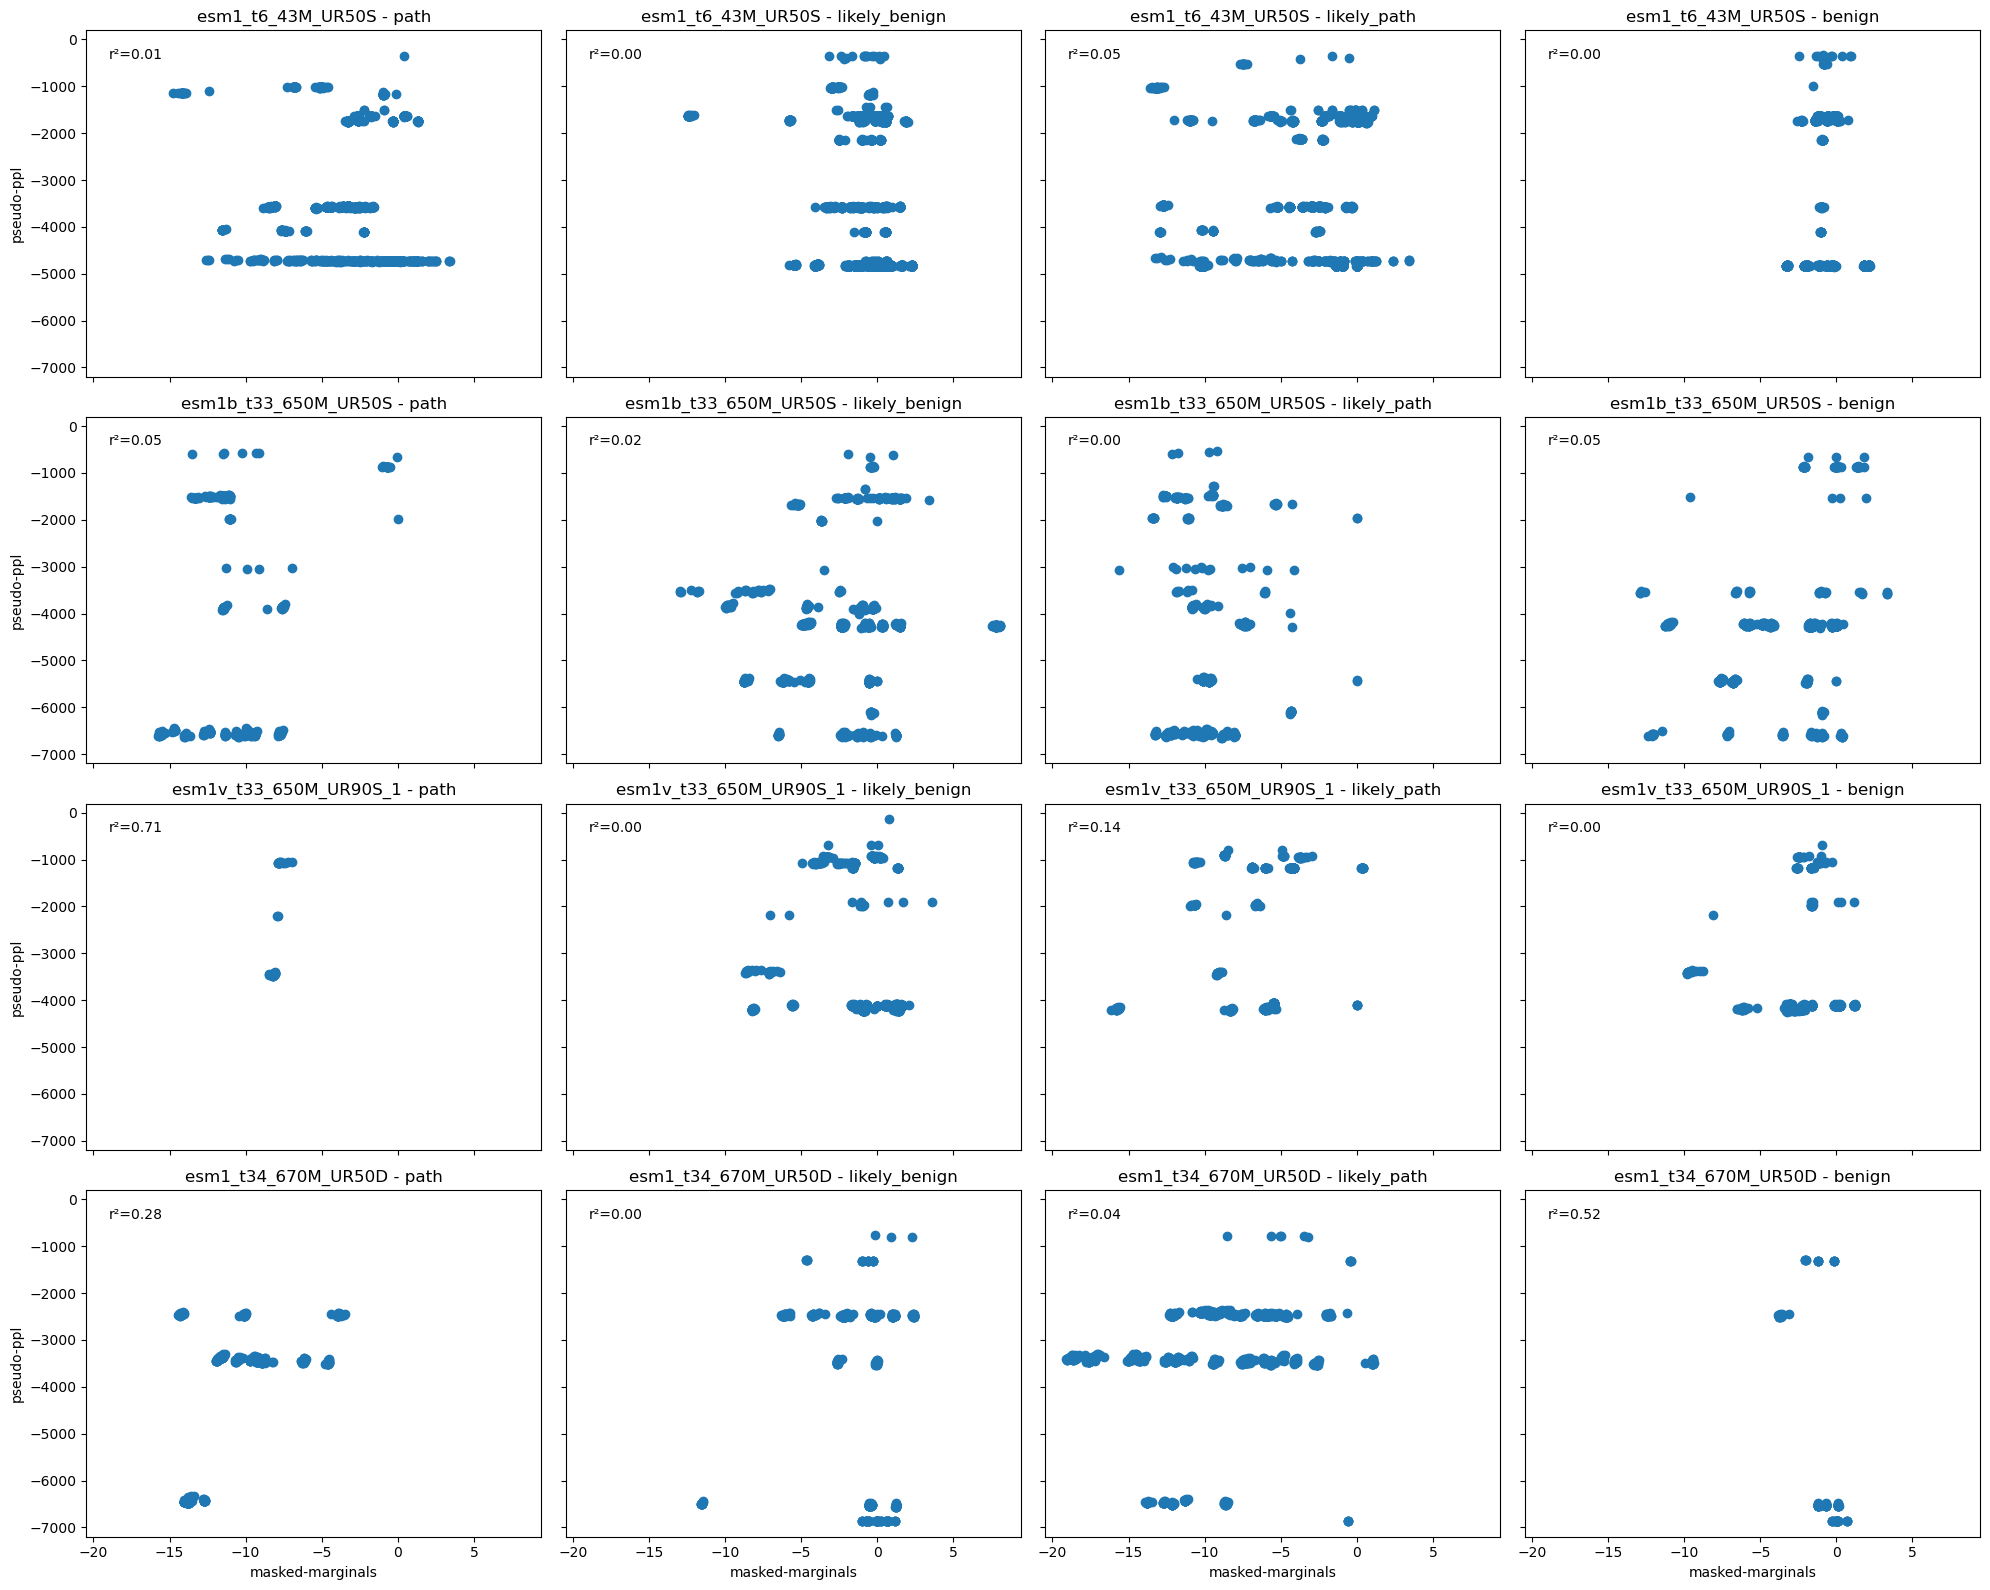

In [14]:

# keep only needed strategies
df = vep_df[vep_df['scoring_strategy'].isin(['masked-marginals', 'pseudo-ppl'])]

# pivot, include clinsig
pt = df.pivot_table(index=['haplotype','protein','mutant','model_location','clinsig'],
                    columns='scoring_strategy', values='VEP', aggfunc='first')

# require both present
pt = pt.dropna(subset=['masked-marginals','pseudo-ppl']).reset_index()

# colormap for clinsig
clinsig_unique = pt['clinsig'].unique()
color_map = {val: i for i, val in enumerate(clinsig_unique)}

# build dict
models = pt['model_location'].unique()
agg = {}
for m in tqdm(models, total=len(models)):
    g = pt[pt['model_location'] == m]
    agg[m] = {
        'masked-marginals': g['masked-marginals'].tolist(),
        'pseudo-ppl': g['pseudo-ppl'].tolist(),
        'clinsig': [color_map[val] for val in g['clinsig']]
    }

from scipy.stats import pearsonr

fig, axes = plt.subplots(len(models), len(clinsig_unique),
                         figsize=(5*len(clinsig_unique), 4*len(models)),
                         sharex=True, sharey=True)

for i, m in enumerate(models):
    g = pt[pt['model_location'] == m]
    for j, cls in enumerate(clinsig_unique):
        sub = g[g['clinsig'] == cls]
        axes[i, j].scatter(sub['masked-marginals'], sub['pseudo-ppl'])
        
        if len(sub) > 1:
            r, _ = pearsonr(sub['masked-marginals'], sub['pseudo-ppl'])
            axes[i, j].text(0.05, 0.95, f"r²={r**2:.2f}",
                            transform=axes[i, j].transAxes,
                            ha='left', va='top', fontsize=10)

        axes[i, j].set_title(f"{m} - {cls}")
        if i == len(models)-1:
            axes[i, j].set_xlabel('masked-marginals')
        if j == 0:
            axes[i, j].set_ylabel('pseudo-ppl')

plt.tight_layout()
# plt.savefig('/blue/juannanzhou/palash.sethi/Projects/VEP/VEP_protein/palash_analysis_scripts/results/ppl_vs_marginal_correlation.png')
plt.show()


100%|██████████| 4/4 [00:00<00:00, 1119.38it/s]


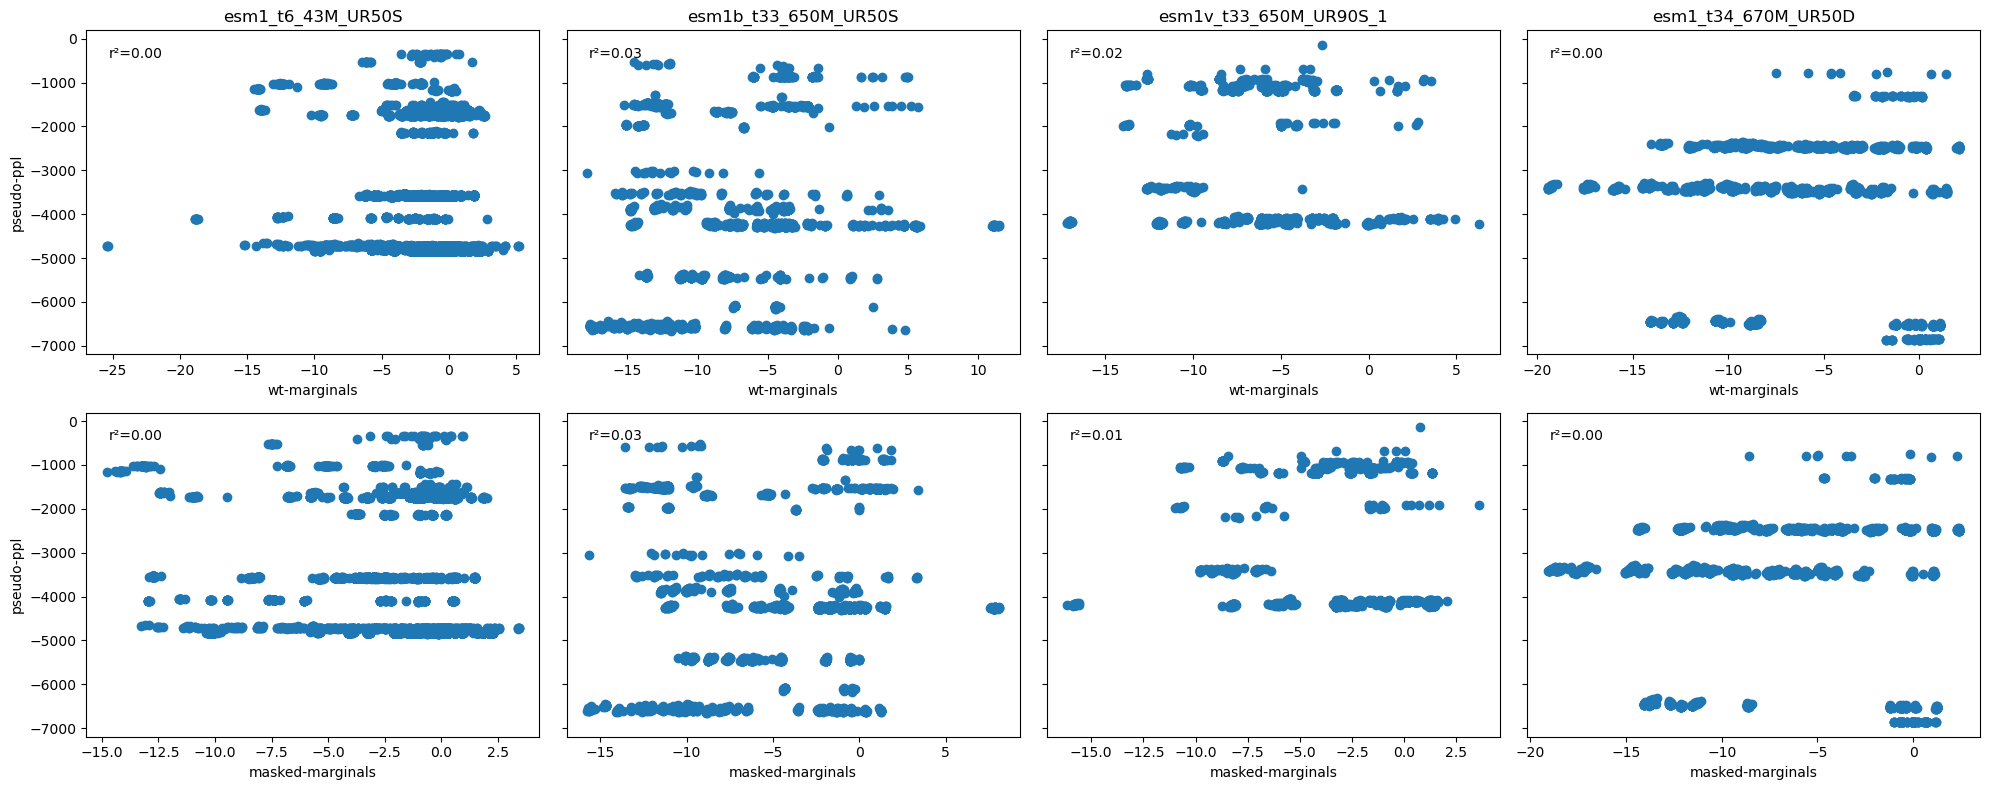

In [15]:
# keep only needed strategies
df = vep_df[vep_df['scoring_strategy'].isin(['masked-marginals','wt-marginals','pseudo-ppl'])]

# pivot, include clinsig (not used in plot but kept if needed later)
pt = df.pivot_table(index=['haplotype','protein','mutant','model_location','clinsig'],
                    columns='scoring_strategy', values='VEP', aggfunc='first').reset_index()

# require all three present
pt = pt.dropna(subset=['masked-marginals','wt-marginals','pseudo-ppl'])

# build dict per model
models = pt['model_location'].unique()
agg = {}
for m in tqdm(models, total=len(models)):
    g = pt[pt['model_location'] == m]
    agg[m] = {
        'wt-marginals': g['wt-marginals'].to_numpy(),
        'masked-marginals': g['masked-marginals'].to_numpy(),
        'pseudo-ppl': g['pseudo-ppl'].to_numpy()
    }

# two rows: (row1) pseudo-ppl vs wt-marginals, (row2) pseudo-ppl vs masked-marginals
fig, axes = plt.subplots(2, len(models), figsize=(5*len(models), 8), sharex=False, sharey='row')
axes = np.atleast_2d(axes)

for i, m in enumerate(models):
    # row 0
    ax0 = axes[0, i]
    ax0.scatter(agg[m]['wt-marginals'], agg[m]['pseudo-ppl'])
    if len(agg[m]['wt-marginals']) > 1:
        r, _ = pearsonr(agg[m]['wt-marginals'], agg[m]['pseudo-ppl'])
        ax0.text(0.05, 0.95, f"r²={r**2:.2f}", transform=ax0.transAxes,
                 ha='left', va='top', fontsize=10)
    ax0.set_title(m)
    if i == 0:
        ax0.set_ylabel('pseudo-ppl')
    ax0.set_xlabel('wt-marginals')

    # row 1
    ax1 = axes[1, i]
    ax1.scatter(agg[m]['masked-marginals'], agg[m]['pseudo-ppl'])
    if len(agg[m]['masked-marginals']) > 1:
        r, _ = pearsonr(agg[m]['masked-marginals'], agg[m]['pseudo-ppl'])
        ax1.text(0.05, 0.95, f"r²={r**2:.2f}", transform=ax1.transAxes,
                 ha='left', va='top', fontsize=10)
    if i == 0:
        ax1.set_ylabel('pseudo-ppl')
    ax1.set_xlabel('masked-marginals')

plt.tight_layout()
plt.show()


In [16]:
# Pivot with all 3 scoring strategies

df = vep_df[vep_df['scoring_strategy'].isin(['wt-marginals','masked-marginals', 'pseudo-ppl'])]
pt = df.pivot_table(
    index=['protein', 'haplotype', 'mutant', 'model_location'],
    columns='scoring_strategy', values='VEP', aggfunc='first'
).reset_index()

var_df = pt.groupby(['protein', 'model_location']).var(numeric_only=True).reset_index()
var_df = var_df.dropna(subset=['wt-marginals','masked-marginals', 'pseudo-ppl'])

model_corrs = {}

for model in var_df['model_location'].unique():
    sub = var_df[var_df['model_location'] == model]
    sub = sub.dropna(subset=['wt-marginals','masked-marginals', 'pseudo-ppl'])
    model_corrs[model] = sub.drop(columns=['protein', 'model_location']).corr()

# Example: print correlation matrix for one model
for model in var_df['model_location'].unique():
    print('===')
    print(model)
    print(model_corrs[model])


===
esm1b_t33_650M_UR50S
scoring_strategy  masked-marginals  pseudo-ppl  wt-marginals
scoring_strategy                                            
masked-marginals          1.000000   -0.113680      0.907821
pseudo-ppl               -0.113680    1.000000     -0.116184
wt-marginals              0.907821   -0.116184      1.000000
===
esm1_t6_43M_UR50S
scoring_strategy  masked-marginals  pseudo-ppl  wt-marginals
scoring_strategy                                            
masked-marginals          1.000000    0.173352      0.869583
pseudo-ppl                0.173352    1.000000      0.338322
wt-marginals              0.869583    0.338322      1.000000
===
esm1_t34_670M_UR50D
scoring_strategy  masked-marginals  pseudo-ppl  wt-marginals
scoring_strategy                                            
masked-marginals          1.000000    0.102379      0.990688
pseudo-ppl                0.102379    1.000000      0.077827
wt-marginals              0.990688    0.077827      1.000000
===
esm1v_t33_

Filtered 27.9% of rows with NAs in col 'VEP'


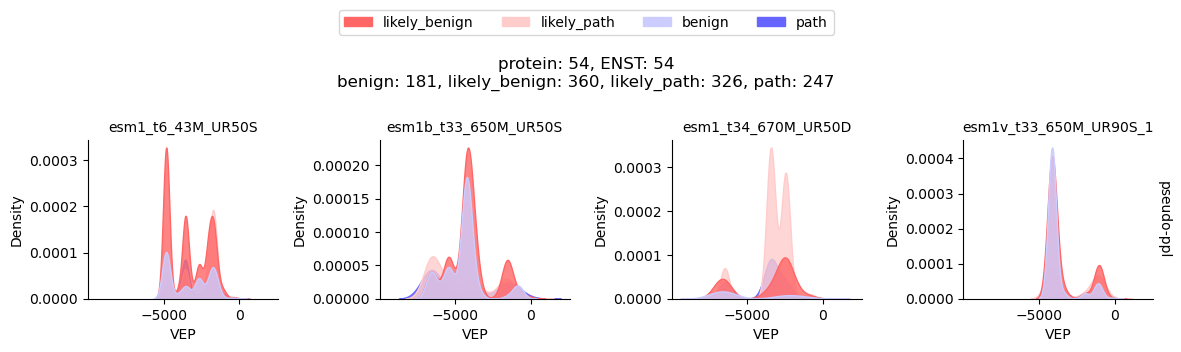

In [17]:
va.plot_vep_density(vep_df[vep_df.scoring_strategy=='pseudo-ppl'], 
                     multiple=['layer','stack','fill'][0],
                     row='scoring_strategy',
                     col='model_location',    
                     legend_y=1.1,
                     aspect=1,
                     # save_path="results/plots/vep_density.png"
                     )

Filtered 0.6% of rows with NAs in col 'VEP'


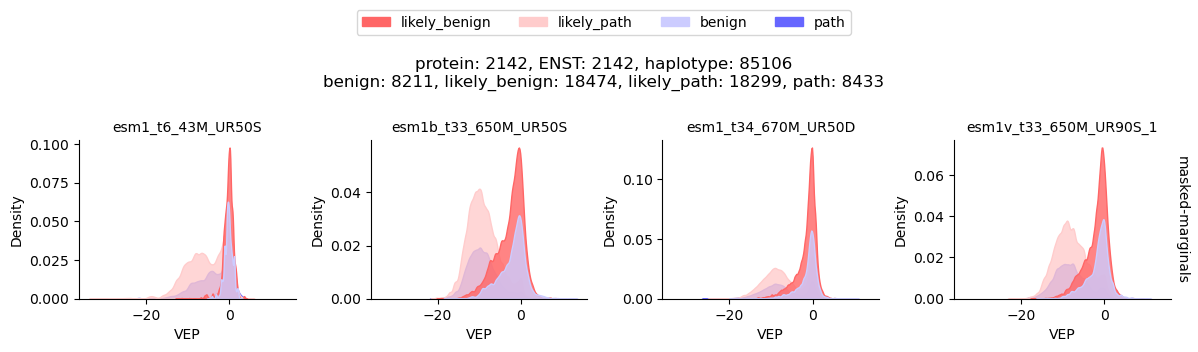

In [18]:
va.plot_vep_density(vep_df[vep_df.scoring_strategy=='masked-marginals'], 
                     multiple=['layer','stack','fill'][0],
                     row='scoring_strategy',
                     col='model_location',    
                     legend_y=1.1,
                     aspect=1,
                     # save_path="results/plots/vep_density.png"
                     )